# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. **What makes a model "linear"? "Linear" in what?**  
A model is "linear" if it is linear in its parameters (coefficients), not necessarily in the variables themselves. This means the model can be written as a linear combination of coefficients and features: $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2$. Even if features are transformed (like $x^2$), the model is still linear as long as the coefficients enter linearly.

2. **How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)**  
A dummy variable coefficient represents the difference in the expected value of the outcome relative to the omitted (baseline) category, holding other variables constant. The intercept corresponds to the baseline group, and each dummy coefficient shows how much higher or lower that group is compared to the baseline.

3. **Can linear regression be used for classification? Explain why, or why not.**  
Linear regression can technically be used for classification by predicting numeric values and thresholding them (e.g., >0.5 = class 1), but it is not ideal. This is because predictions are not constrained between 0 and 1 and the model does not properly model probabilities, making methods like logistic regression more appropriate.

4. **What are signs that your linear model is over-fitting?**  
Signs of overfitting include very high performance on training data but poor performance on test data, overly complex models with many variables, and coefficients that are unstable or highly sensitive to small changes in the data.

5. **Clearly explain multi-colinearity using the two-stage least squares technique.**  
Multicollinearity occurs when explanatory variables are highly correlated, making it difficult to isolate their individual effects. In a two-stage least squares (2SLS) framework, one correlated variable is first regressed on other variables (or instruments) to isolate its independent variation, and then this predicted component is used in the main regression. This helps separate the true effect from shared variation among predictors.

6. **How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?**  
Nonlinear relationships can be incorporated by transforming variables (e.g., squares, logs), adding interaction terms, or using polynomial features. These allow the model to capture curved or more complex relationships while still remaining linear in parameters.

7. **What is the interpretation of the slope coefficient in a linear regression?**  
The slope coefficient represents the expected change in the outcome variable $y$ for a one-unit increase in the predictor variable $x$, holding all other variables constant.

8. **Compare the train/test split and $k$-fold cross validation.**  
A train/test split divides the data once into training and testing sets, while $k$-fold cross validation splits the data into $k$ subsets and rotates which subset is used for validation. Cross validation provides a more reliable estimate of model performance because it uses multiple splits instead of just one.

9. **How is the $k$ in $k$-fold cross validation typically selected?**  
The value of $k$ is chosen based on a trade-off between bias and variance. Common choices are $k=5$ or $k=10$, which balance computational efficiency and reliable performance estimates.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                Price  Review Scores Rating
Neighbourhood                              
Bronx           75.28                 91.65
Brooklyn       127.75                 92.36
Manhattan      183.66                 91.80
Queens          96.86                 91.55
Staten Island  146.17                 90.84

Most expensive borough: Manhattan


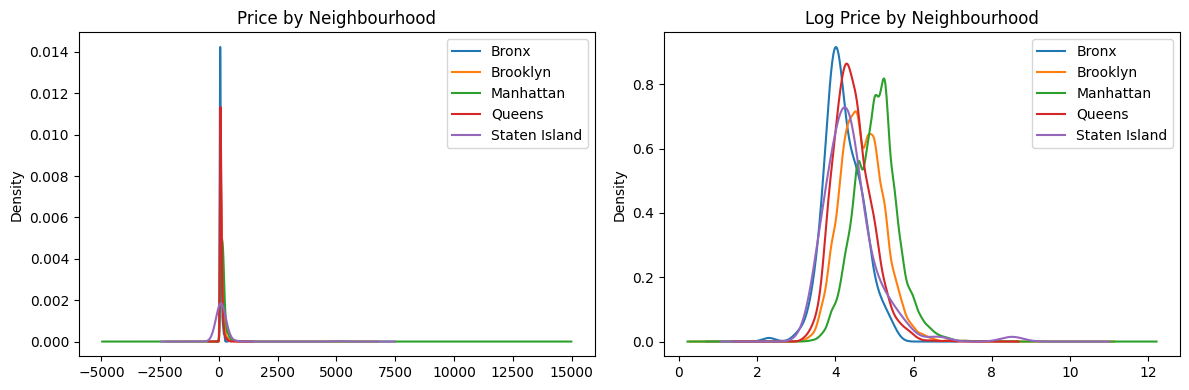

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Q1_clean.csv')
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price', 'Review Scores Rating', 'Neighbourhood'])

# Average prices and scores by neighbourhood
group_means = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().round(2)
print(group_means)
print(f"\nMost expensive borough: {group_means['Price'].idxmax()}")

# KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hood, group in df.groupby('Neighbourhood'):
    group['Price'].plot.kde(ax=axes[0], label=hood)
    np.log(group['Price']).plot.kde(ax=axes[1], label=hood)
axes[0].set_title('Price by Neighbourhood')
axes[1].set_title('Log Price by Neighbourhood')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

Manhattan is the most expensive borough on average at 183.66/night. The raw price KDE is heavily skewed by outliers, but the log price KDE shows distributions are more symmetric. Manhattan clearly sits at the higher end while the Bronx is the cheapest borough.

In [29]:
# Drop first category (Bronx = reference), keep intercept
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X = sm.add_constant(dummies)
model_hood = sm.OLS(df['Price'], X).fit()
print(model_hood.summary())

# Compare coefficients to group means
print("\nGroup means vs coefficients:")
print(f"Bronx (reference) mean: {df[df['Neighbourhood']=='Bronx']['Price'].mean():.2f} = intercept")
print("Each coefficient = that borough's mean minus Bronx mean")
print((group_means['Price'] - group_means['Price']['Bronx']).round(2))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        22:21:52   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

We drop the first category (Bronx) and keep the intercept, so the intercept equals the Bronx mean price (75.28). Each coefficient represents the difference in average price relative to the Bronx. Manhattan listings are on average 108.39 more expensive than Bronx listings, and Staten Island is 70.89 more expensive. These match exactly with the group means from part 1 (group mean minus Bronx mean).

In [30]:
X2 = sm.add_constant(df['Review Scores Rating'])
model_scores = sm.OLS(df['Price'], X2).fit()
print(model_scores.summary())

slope = model_scores.params['Review Scores Rating']
print(f"\nInterpretation: A one-unit increase in review score is associated with a ${slope:.2f} change in nightly price, holding all else constant.")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:22:23   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

A one-unit increase in review score is associated with a 1.02 increase in nightly price, holding all else constant. However, the R-squared is only 0.004, meaning review scores alone explain very little of the variation in price.

In [31]:
X3 = sm.add_constant(pd.concat([dummies, df['Review Scores Rating']], axis=1))
model_both = sm.OLS(df['Price'], X3).fit()
print(model_both.summary())

print(f"\nReview Scores slope (scores only):      {model_scores.params['Review Scores Rating']:.4f}")
print(f"Review Scores slope (with neighbourhood): {model_both.params['Review Scores Rating']:.4f}")
print("Neighbourhood coefficients now represent price differences controlling for review scores.")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        22:23:00   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

After controlling for neighbourhood, the slope on review scores increases slightly from 1.02 to 1.05. The neighbourhood coefficients remain similar to part 2, suggesting review scores and neighbourhood are largely independent of each other. Controlling for neighbourhood does not meaningfully change the effect of review scores on price.

In [32]:
# Interact each neighbourhood dummy with Review Scores Rating
interact = dummies.multiply(df['Review Scores Rating'], axis=0)
interact.columns = [f'{c}_x_rating' for c in interact.columns]
X4 = sm.add_constant(pd.concat([df['Review Scores Rating'], dummies, interact], axis=1))
model_interact = sm.OLS(df['Price'], X4).fit()
print(model_interact.summary())
print("\nThe base slope applies to Bronx; interaction terms show how each borough's slope differs from Bronx.")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:23:22   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     22

Most interaction terms are small and statistically insignificant, suggesting the slope on review scores is similar across boroughs. The exception is Staten Island, which has a very large and significant interaction term (-31.83), meaning the relationship between review scores and price is very different there compared to other boroughs. This is likely driven by the small sample size for Staten Island rather than a genuine difference in the relationship.

In [33]:
y = df['Price']

def rmse_cv(X, y, cv=5):
    scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_root_mean_squared_error')
    return -scores.mean()

print(f"Model 4 (neighbourhood + rating) RMSE:       {rmse_cv(X3, y):.2f}")
print(f"Model 5 (neighbourhood only) RMSE:           {rmse_cv(X, y):.2f}")
print(f"Model 6 (interaction slopes) RMSE:           {rmse_cv(X4, y):.2f}")

Model 4 (neighbourhood + rating) RMSE:       142.83
Model 5 (neighbourhood only) RMSE:           143.14
Model 6 (interaction slopes) RMSE:           143.86


All three models have very similar RMSE (around 143), suggesting that adding review scores and interaction terms provides minimal improvement in predictive accuracy over neighbourhood alone. The interaction model actually performs slightly worse, likely due to the noisy Staten Island interaction term adding variance without improving generalization.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

df3 = pd.read_csv('./data/cars_hw.csv')
print(df3.columns.tolist())
print(df3.head(3))
print(df3['Price'].describe())

['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'Price']
   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Pric

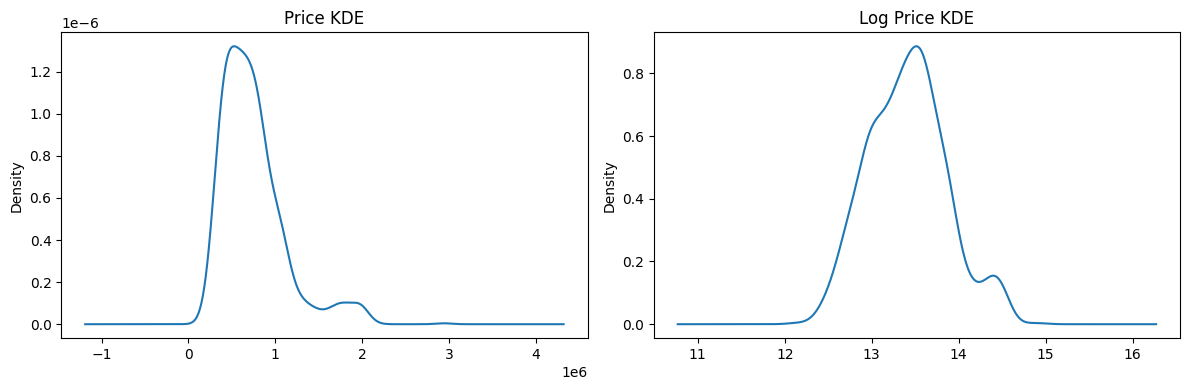

           count       mean       std       min       25%        50%  \
Body_Type                                                              
crossover   21.0   705095.0   72850.0  608000.0  638000.0   706000.0   
hatchback  484.0   533977.0  173087.0  188000.0  401750.0   509000.0   
muv         38.0   626421.0  184093.0  328000.0  489750.0   621500.0   
sedan      227.0   809784.0  286737.0  368000.0  598000.0   772000.0   
suv        206.0  1176495.0  417479.0  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


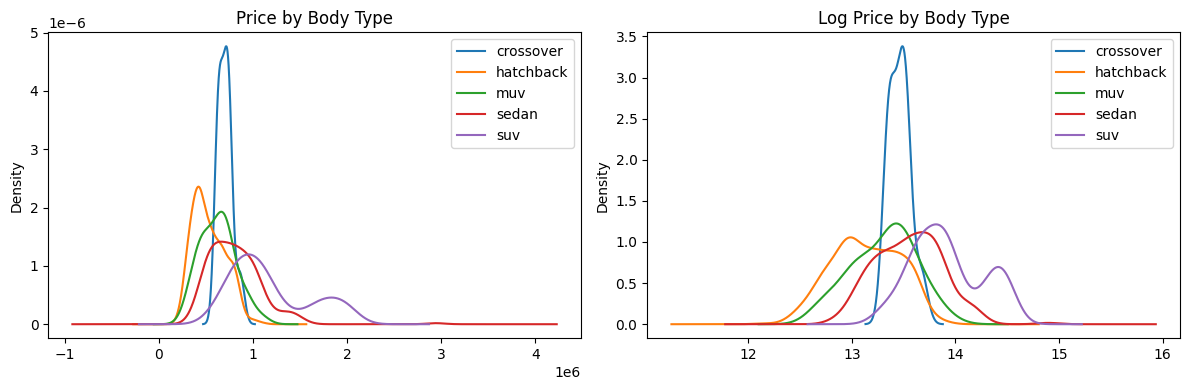

In [19]:
# Price summary and KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df3['Price'].plot.kde(ax=axes[0])
axes[0].set_title('Price KDE')
np.log(df3['Price']).plot.kde(ax=axes[1])
axes[1].set_title('Log Price KDE')
plt.tight_layout()
plt.show()

# Summary by Body_Type
print(df3.groupby('Body_Type')['Price'].describe().round(0))

# Grouped KDE by Body_Type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for body, group in df3.groupby('Body_Type'):
    group['Price'].plot.kde(ax=axes[0], label=body)
    np.log(group['Price']).plot.kde(ax=axes[1], label=body)
axes[0].set_title('Price by Body Type')
axes[1].set_title('Log Price by Body Type')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

SUVs are the most expensive body type on average (mean ~1,176,495 rupees) and also have the most variance (std ~417,479). Hatchbacks are the cheapest on average (mean ~533,977). The log price KDE shows the distributions are more symmetric, and the grouped plot confirms SUVs and sedans sit at the higher end while hatchbacks cluster at the lower end.

In [20]:
# Linear regression on Seating_Capacity
X = sm.add_constant(df3['Seating_Capacity'])
model_seats = sm.OLS(df3['Price'], X).fit()
print(model_seats.summary())
print(f"\nSlope: a one-seat increase is associated with a {model_seats.params['Seating_Capacity']:.0f} rupee change in price.")

# Treat Seating_Capacity as categorical
seat_dummies = pd.get_dummies(df3['Seating_Capacity'], drop_first=True, dtype=int)
X_cat = sm.add_constant(seat_dummies)
model_seats_cat = sm.OLS(df3['Price'], X_cat).fit()
print(model_seats_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:03:48   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

When treated as continuous, each additional seat is associated with a 59,268 rupee increase in price. However, when treated as categorical, the coefficients are not monotonically increasing. Six-seat cars are much more expensive than seven-seat cars (1,456,000 vs 735,900 above the reference), suggesting the relationship is not strictly linear in the number of seats. The jump from 5 to 6 seats is particularly large, likely reflecting that 6-seat configurations appear in premium vehicles.

In [21]:
df3['Age'] = 2026 - df3['Make_Year']

best_degree, best_rmse = 1, np.inf
results = []
for degree in range(1, 11):
    poly_features = np.column_stack([df3['Age']**i for i in range(1, degree+1)])
    scores = cross_val_score(LinearRegression(), poly_features, df3['Price'],
                             cv=10, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    results.append((degree, rmse))
    if rmse < best_rmse:
        best_rmse = rmse
        best_degree = degree

for degree, rmse in results:
    print(f"Degree {degree}: RMSE = {rmse:.0f}")
print(f"\nOptimal degree: {best_degree}")

Degree 1: RMSE = 307577
Degree 2: RMSE = 308060
Degree 3: RMSE = 307441
Degree 4: RMSE = 307881
Degree 5: RMSE = 307742
Degree 6: RMSE = 308128
Degree 7: RMSE = 307251
Degree 8: RMSE = 307646
Degree 9: RMSE = 307879
Degree 10: RMSE = 307845

Optimal degree: 7


Using 10-fold cross validation across polynomial degrees 1 through 10, the optimal degree is 7 with an RMSE of 307,251. However, the RMSE values are very similar across all degrees (ranging from ~307,000 to ~308,000), suggesting that higher-order polynomial terms provide minimal additional predictive power and a simpler model would work nearly as well.

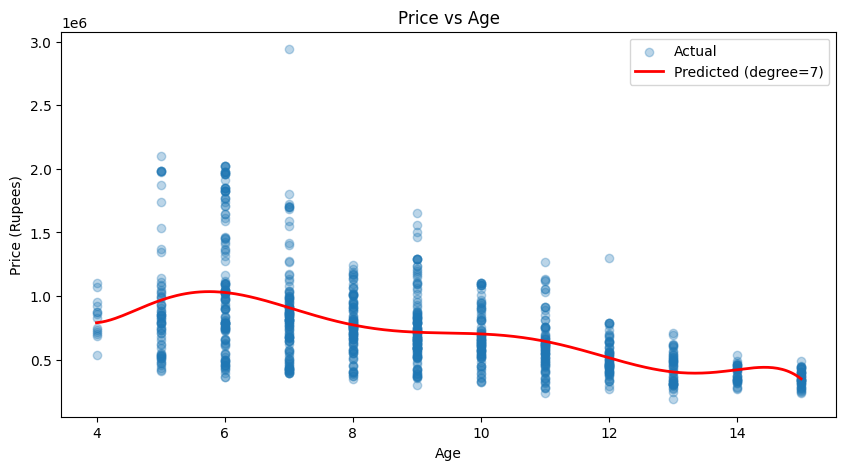

In [22]:
# Fit best model
poly_features = np.column_stack([df3['Age']**i for i in range(1, best_degree+1)])
best_model = LinearRegression().fit(poly_features, df3['Price'])
df3['Predicted_Price'] = best_model.predict(poly_features)

# Plot
age_range = np.linspace(df3['Age'].min(), df3['Age'].max(), 300)
age_range_poly = np.column_stack([age_range**i for i in range(1, best_degree+1)])
predicted_range = best_model.predict(age_range_poly)

plt.figure(figsize=(10, 5))
plt.scatter(df3['Age'], df3['Price'], alpha=0.3, label='Actual')
plt.plot(age_range, predicted_range, color='red', linewidth=2, label=f'Predicted (degree={best_degree})')
plt.xlabel('Age')
plt.ylabel('Price (Rupees)')
plt.title('Price vs Age')
plt.legend()
plt.show()

The model captures the general downward trend in price as vehicle age increases, which makes intuitive sense as cars depreciate over time. The degree-7 polynomial fits the broad pattern reasonably well but the fit is loose given the wide spread of prices at each age. The model struggles with the high variance in the data, particularly for newer cars where prices vary widely depending on make and body type. Overall the model captures the trend but age alone is not a strong predictor of price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [35]:
# Proportion surviving in each group
control_survival = df4[df4['transplant'] == 'control']['y'].mean()
treatment_survival = df4[df4['transplant'] == 'treatment']['y'].mean()
ATE = treatment_survival - control_survival

print(f"Control survival rate:   {control_survival:.4f}")
print(f"Treatment survival rate: {treatment_survival:.4f}")
print(f"ATE (treatment - control): {ATE:.4f}")

Control survival rate:   0.1176
Treatment survival rate: 0.3478
ATE (treatment - control): 0.2302


The control group has a survival rate of 11.76% while the treatment group has a survival rate of 34.78%. The average treatment effect (ATE) is 0.23, meaning heart transplant recipients are about 23 percentage points more likely to survive three years than those who did not receive a transplant.

In [36]:
df4['transplant_dummy'] = (df4['transplant'] == 'treatment').astype(int)
X = sm.add_constant(df4['transplant_dummy'])
model_transplant = sm.OLS(df4['y'], X).fit()
print(model_transplant.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        22:25:26   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

The intercept (0.1176) equals the control group survival rate and the transplant coefficient (0.2302) equals the ATE from part 1. This confirms that a simple regression of y on a binary treatment indicator recovers exactly the group means and their difference.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        22:25:50   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7020      0.196  

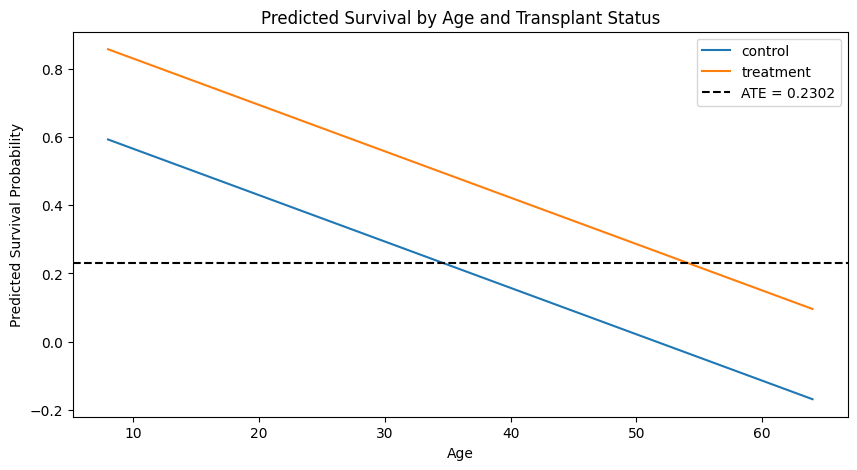

In [37]:
X3 = sm.add_constant(df4[['transplant_dummy', 'age']])
model_age = sm.OLS(df4['y'], X3).fit()
print(model_age.summary())

# Plot predicted probability by age for each group
age_range = np.linspace(df4['age'].min(), df4['age'].max(), 100)

fig, ax = plt.subplots(figsize=(10, 5))
for group, val in [('control', 0), ('treatment', 1)]:
    X_plot = pd.DataFrame({'const': 1, 'transplant_dummy': val, 'age': age_range})
    preds = model_age.predict(X_plot)
    ax.plot(age_range, preds, label=group)

ax.axhline(ATE, color='black', linestyle='--', label=f'ATE = {ATE:.4f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival by Age and Transplant Status')
ax.legend()
plt.show()

After controlling for age, the transplant coefficient increases slightly from 0.2302 to 0.2647, suggesting the raw ATE slightly underestimates the effect of transplants once we account for age differences between groups. The age coefficient (-0.0136) indicates that each additional year of age is associated with a 1.36 percentage point decrease in survival probability. The intercept (0.702) represents the predicted survival probability for a newborn in the control group, which is not a meaningful value given the data range.

From the plot, the ATE of 0.23 overestimates the transplant benefit for younger patients (where the gap between the two lines is larger than the ATE line) and underestimates it for older patients. The two lines are parallel since there is no interaction term, meaning the model assumes the transplant effect is constant across all ages.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:26:32   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

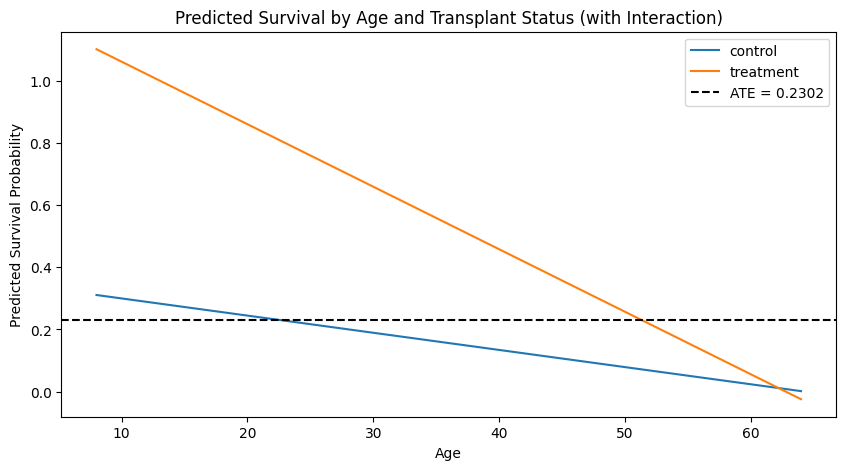

In [38]:
df4['transplant_age'] = df4['transplant_dummy'] * df4['age']
X4 = sm.add_constant(df4[['transplant_dummy', 'age', 'transplant_age']])
model_interact = sm.OLS(df4['y'], X4).fit()
print(model_interact.summary())

fig, ax = plt.subplots(figsize=(10, 5))
for group, val in [('control', 0), ('treatment', 1)]:
    X_plot = pd.DataFrame({
        'const': 1,
        'transplant_dummy': val,
        'age': age_range,
        'transplant_age': val * age_range
    })
    preds = model_interact.predict(X_plot)
    ax.plot(age_range, preds, label=group)

ax.axhline(ATE, color='black', linestyle='--', label=f'ATE = {ATE:.4f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival by Age and Transplant Status (with Interaction)')
ax.legend()
plt.show()

Adding the interaction term reveals that the benefit of a transplant decreases with age. The transplant coefficient (0.9078) now represents the effect of a transplant at age zero, and the interaction term (-0.0146) shows that the transplant benefit shrinks by about 1.46 percentage points for each additional year of age. The two lines are no longer parallel, with the treatment group showing a steeper decline in predicted survival as age increases. This suggests transplants are most beneficial for younger patients and the benefit diminishes for older patients, eventually converging with the control group around age 60.

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

y = df4['y']

def rmse_cv(X, y, cv=10):
    scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_root_mean_squared_error')
    return -scores.mean()

X2 = df4[['transplant_dummy']]
X3 = df4[['transplant_dummy', 'age']]
X4 = df4[['transplant_dummy', 'age', 'transplant_age']]

print(f"Model 2 (transplant only) RMSE:        {rmse_cv(X2, y):.4f}")
print(f"Model 3 (transplant + age) RMSE:       {rmse_cv(X3, y):.4f}")
print(f"Model 4 (transplant + age + interaction) RMSE: {rmse_cv(X4, y):.4f}")

Model 2 (transplant only) RMSE:        0.4355
Model 3 (transplant + age) RMSE:       0.4212
Model 4 (transplant + age + interaction) RMSE: 0.4129


Model 4 with the interaction term has the lowest RMSE (0.4129), followed by Model 3 (0.4212) and Model 2 (0.4355). Adding age and the interaction term both improve predictive accuracy, suggesting that age is a meaningful predictor of survival and that the transplant effect genuinely varies with age.

There are several concerns with using this model to prioritize transplant access. The dataset only has 103 observations, making estimates unstable for a high-stakes medical decision. The model also only includes age and transplant status, ignoring clinically relevant factors like disease severity and overall health. Using age as a primary factor raises ethical concerns about discrimination against older patients who would be systematically deprioritized. Finally, model errors are not symmetric in this context since denying a life-saving transplant to someone who would have benefited is far more costly than the reverse, and standard RMSE does not capture this.